#Solución numerica de la ecuacion differencial

###**Ejemplo 1:**

Resolvamos numericamente la ecuacion diferencial usando la libreria scipy (a manera de caja negra 🙃!)


\begin{equation}
 \dfrac{d P(t)}{dt} = P (\alpha - \beta P(t))
\end{equation}

<br>

Con:

- $P(0) = 0.2 $

- $\alpha = 0.5$

- $\beta = 0.1$

Graficaremos la solucion numerica obtenida y  tambien la fucion constante $\alpha / \beta$, la cual establece el punto limite de crecimiento.


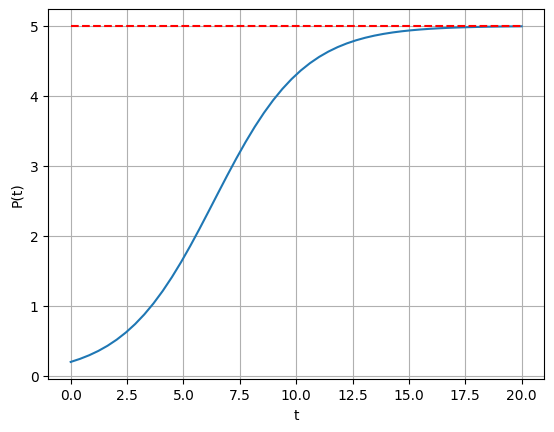

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#---------------------------------
from scipy.integrate import odeint
#---------------------------------



#---parametros del modelo--
beta  = 0.1
alpha = 0.5
#--------------------------


#----- modelo-------
def modelo(p,t):
    return p*( alpha - beta * p)
#--------------------



#poblacion inicial
P0 = 0.2

#lista de tiempo
t = np.linspace(0,20)



#resolviendo la ODE usndo scipy!
P = odeint(modelo,P0,t)


# plot results
plt.plot(t,P)


#------introducir linea constante: B/alpha-------------
plt.plot(t,    np.ones_like(t) *   alpha/beta , 'r--' )
#------------------------------------------------------

plt.grid()
plt.xlabel('t')
plt.ylabel('P(t)')
plt.show()

###¿Que pasa si usamos varias condiciones iniciales para la ODE?

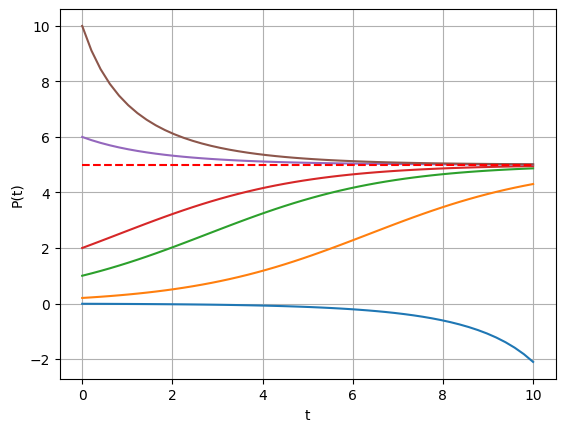

In [ ]:

#poblaciones iniciales
lista_poblaciones_iniciales = [-0.01, 0.2, 1 , 2 , 6, 10 ]


#lista de tiempo
t = np.linspace(0,10)


for Po in lista_poblaciones_iniciales:
    #resolviendo la ODE
    P = odeint(modelo,Po,t)


    #graficamos las funciones obtenidas :)
    plt.plot(t,P)


#------introducir linea constante: B/alpha-------------
plt.plot(t,    np.ones_like(t) *   alpha/beta , 'r--' )
#------------------------------------------------------

plt.grid()
plt.xlabel('t')
plt.ylabel('P(t)')
plt.show()


**Conclusión :** Sin importar el valor de las condiciones iniciales, el  sistema parece evolucionar asintoticamente hacia el mismo valor!!!. Este valor parece atraer todas las soluciones!!!

> Respuesta: decimos que el punto valor es un punto critico del sistema de tipo estable.

##**Ejemplo 2:**


Resolvamos numericamente la ecuacion diferencial usando la libreria scipy (a manera de caja negra 🙃!)


\begin{equation}
 \dfrac{d P(t)}{dt} = k P(t)  
\end{equation}

<br>

Con:

- $P(0) = 0.2 $

- $k = 0.2$


Graficaremos la solucion numerica obtenida y  tambien la fucion constante $0$, la cual establece el punto de equilibrio.


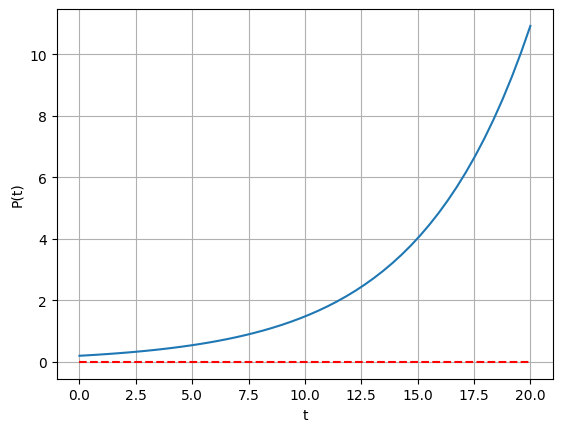

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#---------------------------------
from scipy.integrate import odeint
#---------------------------------



#---parametros del modelo--
k = 0.2
#--------------------------


#----- modelo-------
def modelo(p,t):
    return k * p
#--------------------



#poblacion inicial
P0 = 0.2

#lista de tiempo
t = np.linspace(0,20)


#resolviendo la ODE
P = odeint(modelo,P0,t)


# plot results
plt.plot(t,P)


#------introducir linea constante: 0-------------
plt.plot(t,    np.ones_like(t) *   0  , 'r--' )
#------------------------------------------------------

plt.grid()
plt.xlabel('t')
plt.ylabel('P(t)')
plt.show()

###¿Que pasa si usamos varias condiciones iniciales para la ODE?

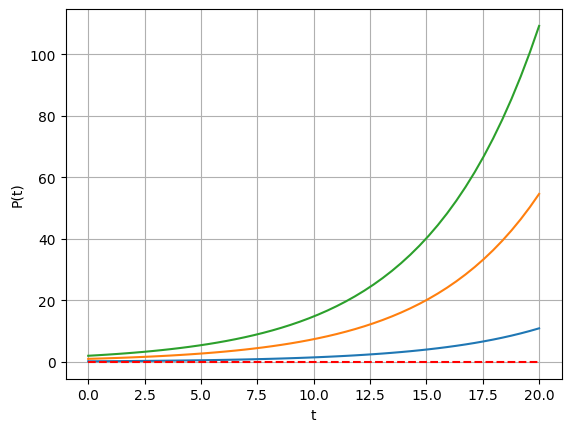

In [ ]:

#poblaciones iniciales
lista_poblaciones_iniciales = [ 0.2, 1 , 2 ]


#lista de tiempo
t = np.linspace(0,20)


for Po in lista_poblaciones_iniciales:
    #resolviendo la ODE
    P = odeint(modelo,Po,t)


    #graficamos las funciones obtenidas :)
    plt.plot(t,P)


#------introducir linea constante: B/alpha-------------
plt.plot(t,    np.ones_like(t) *   0 , 'r--' )
#------------------------------------------------------

plt.grid()
plt.xlabel('t')
plt.ylabel('P(t)')
plt.show()

**Conclusión :** Sin importar el valor de las condiciones iniciales, el *punto critico* parece repeler todas las soluciones!!!


> Entonces: decimos que el punto critico es un repulsor, o punto de silla.

#Campo de velocidades

Suponga la ecuación diferencial

\begin{equation}
\dfrac{dy(t)}{dt} = f(t,y)
\end{equation}

El campo de velocidades en el plano $(t,y)$ evaluado en cierto punto $(t_0,y_0)$ se define como el vector

\begin{equation}
u \big|_{t_0,y_0}  = (u_1 , u_2) :=\dfrac{1}{\sqrt{ V_1^2 +  V_2^2 } } ( V_1 ,  V_2)
\end{equation}

donde $ V_1 = \dfrac{dt}{dt}= 1$ y  $V_2 = \dfrac{dy}{dt} \big|_{t_0,y_0} $.


El campo de velocidades nos sirve para obtener información "cualitativa" del comportamiento de la solución a la ecuación diferencial. En particular podemos obtener información de:

- Puntos de equilibrio (sumideros).
- Puntos de silla (repulsores).
- Regiones de crecimiento y decrecimiento dependiendo de la condición inicial.

**Nota**: ¡No tenemos que resolver la ecuación para hallar su campo de velocidades!


### Ejemplo

Considere el siguiente problema de evolución

\begin{equation}
 \dfrac{d P(t)}{dt} = P (\alpha - \beta P(t))
\end{equation}

con $\alpha=0.5$ y $\beta=0.1$.

- Encuentre el campo de velocidades de la ecuación diferencial en un intervalo de tiempo $[0, 10]$ para diferentes condiciones iniciales $y_0$ entre $[-2, 2]$.

- Usando el campo de velocidades estime, si existen, los puntos de equilibrio y de silla.

- Usando el campo de velocidades estime para qué valores de las condiciones iniciales la solución deberá ser creciente o decreciente.



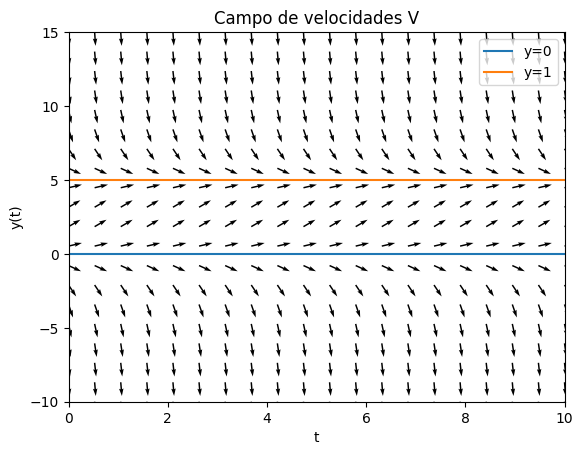

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


alpha= 0.5
beta = 0.1

#--------Ecuacion diferencial-----
def Ec_differencial(p):
    # dy/dt = f(t,y)
    dpdt = p*(alpha-beta * p)
    return dpdt
#---------------------------------

#---Definiendo parametros---
t0 = 0
tf = 10

ymin = -10
ymax =  15
#---------------------------

#Numero de puntos
N   =  20

#valores del tiempo
t  = np.linspace(t0, tf, N)

#valores de la funcion
y  = np.linspace(ymin,ymax, N)

#Creando la malla de puntos (t,Y)
T, Y = np.meshgrid(t, y)



#-------------Vector de velocidades ------------------
#componente horizontal
Vx = 1

#componente vertical
Vy = Ec_differencial(Y)

#Normalizando el vector
Norma = np.sqrt(Vx**2 + Vy**2)
ux = Vx / Norma
uy = Vy / Norma
#----------------------------------------------------

#graficando el campo de velocidades
plt.quiver(T, Y, ux, uy )
plt.title("Campo de velocidades V")
plt.xlabel('t')
plt.ylabel('y(t)')
plt.axis([t0, tf, ymin, ymax])


#Adicionando rectas horizintales
plt.plot( t , 0.* np.ones_like( t )      , label="y=0" )
plt.plot( t , (alpha/beta)* np.ones_like( t )  , label="y=1")
plt.legend()


plt.show()





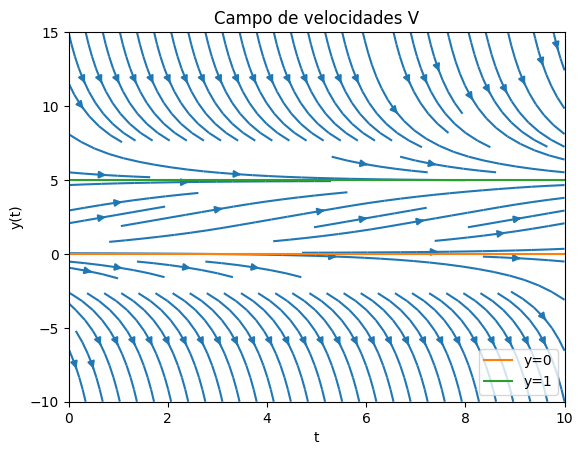

In [ ]:
#Alternativa para graficar campos de velocidades
plt.streamplot(T, Y, ux, uy,density = 1)
plt.title("Campo de velocidades V")
plt.xlabel('t')
plt.ylabel('y(t)')
plt.axis([t0, tf, ymin, ymax])


#Adicionando rectas horizintales
plt.plot( t , 0.* np.ones_like( t )      , label="y=0" )
plt.plot( t , (alpha/beta)* np.ones_like( t )  , label="y=1")
plt.legend()



plt.show()

Del campo de velocidades podemos inferir lo siguiente:

- El punto de equilibrio es : y=5


- El punto de silla es : y= 0

- La solución es creciente para condiciones iniciales $y_0$ en $(5,0)$, pero nunca sobrepasaran el valor de 5.

- La solución es decreciente para condiciones iniciales $y_0$ en $(\infty,5)$ y  $(0,-\infty)$. En el primer caso decaen al valor de $5$ y en el segundo caso no se puede establecer con el campo de velocidades obtenido.


### Ejemplo 2

Considere el siguiente problema de evolución

\begin{equation}
 \dfrac{d P(t)}{dt} = k P
\end{equation}

con $k=0.2$.  

- Encuentre el campo de velocidades de la ecuación diferencial en un intervalo de tiempo $[0, 10]$ para diferentes condiciones iniciales $y_0$ entre $[-2, 2]$.

- Usando el campo de velocidades estime, si existen, los puntos de equilibrio y de silla.

- Usando el campo de velocidades estime para qué valores de las condiciones iniciales la solución deberá ser creciente o decreciente.



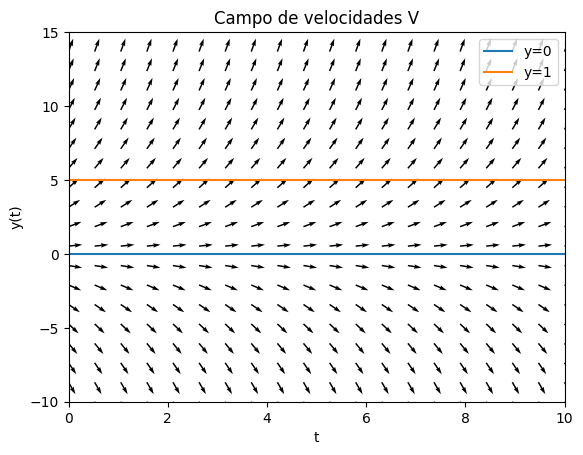

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

k = 0.2

#--------Ecuacion diferencial-----
def Ec_differencial(p):
    # dy/dt = f(t,y)
    dpdt = p*k
    return dpdt
#---------------------------------

#---Definiendo parametros---
t0 = 0
tf = 10

ymin = -10
ymax =  15
#---------------------------

#Numero de puntos
N   =  20

#valores del tiempo
t  = np.linspace(t0, tf, N)

#valores de la funcion
y  = np.linspace(ymin,ymax, N)

#Creando la malla de puntos (t,Y)
T, Y = np.meshgrid(t, y)

#-------------Vector de velocidades ------------------
#componente horizontal
Vx = 1

#componente vertical
Vy = Ec_differencial(Y)

#Normalizando el vector
Norma = np.sqrt(Vx**2 + Vy**2)
ux = Vx / Norma
uy = Vy / Norma
#----------------------------------------------------

#graficando el campo de velocidades
plt.quiver(T, Y, ux, uy )
plt.title("Campo de velocidades V")
plt.xlabel('t')
plt.ylabel('y(t)')
plt.axis([t0, tf, ymin, ymax])


#Adicionando rectas horizintales
plt.plot( t , 0.* np.ones_like( t )      , label="y=0" )
plt.legend()


plt.show()


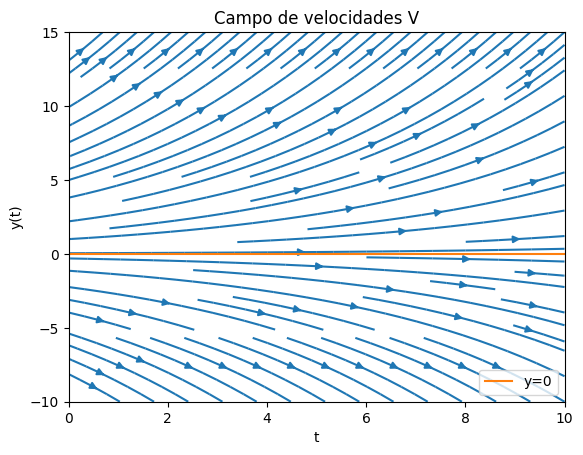

In [ ]:
#Alternativa para graficar campos de velocidades
plt.streamplot(T, Y, ux, uy,density = 1)
plt.title("Campo de velocidades V")
plt.xlabel('t')
plt.ylabel('y(t)')
plt.axis([t0, tf, ymin, ymax])


#Adicionando rectas horizontales
plt.plot( t , 0.* np.ones_like( t )      , label="y=0" )
plt.legend()


plt.show()